Simple example of EnKF assimilation on the Lorenz-96 system.

The system state is composed of $N$ variables $x_1, ..., x_N$ with periodic boundaries (i.e. $x_{N+1} = x_{1}, x_{0} = x_N, x_{-1} = x_{N-1}$).

For $i=1, ..., N$, its evolution is described by:

$\frac{dx_i}{dt} = (x_{i+1} - x_{i-2}) x_{i-1} - x_i + F$

We will use the most common choices $N=40$ and $F=8$.

# Generation of groundtruth trajectory and observations

In [1]:
import os
import torch
from matplotlib import pyplot as plt
from time import time
from tensordict import TensorDict
from mdml_sim.lorenz96 import L96Simulator
os.chdir('..')
from adda.system.state import State
from adda.observation.operators import random_sparse_noisy_obs
from adda.util.initialization import naive_initialization
from adda.util.visualization import show_1dseqimg, plot_ensemble_analysis
# Import the EnKF and EnKS classes
from adda.ensemble.enkf import EnKF, enkf
from adda.ensemble.enks import EnKS, enks

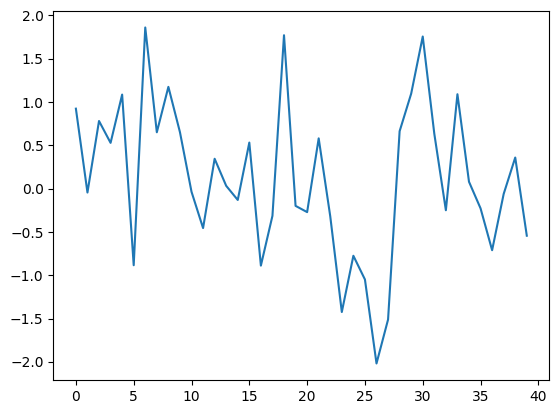

In [2]:
# Define a target initial state
n_variables = 40 # N = 40
initial_state = State(torch.randn(1, 1, n_variables))  # (batch, time, n_variables)
plt.plot(initial_state.fields['x'].squeeze())

torch.Size([1600, 40])


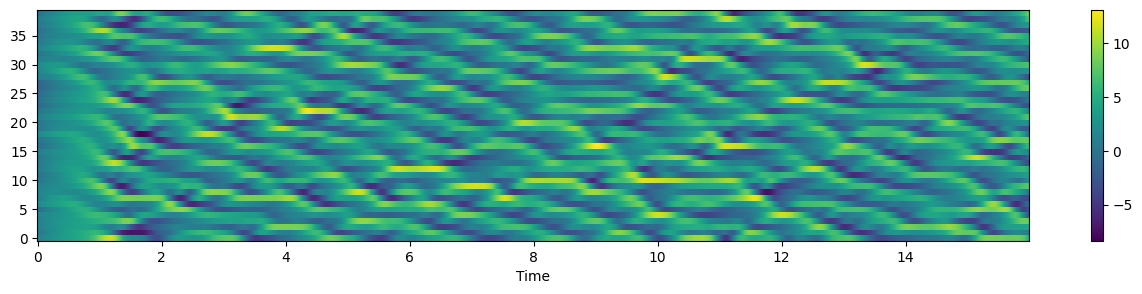

In [3]:
# Generate a time series from the defined initial_condition using our L96 simulator
forward_operator = L96Simulator(forcing=8.0) # F = 8
ts_length = 1600
time_step = 0.01 # one time step = 0.01 second
forecast_steps = torch.arange(0, ts_length * time_step, time_step)
ts = forward_operator.integrate(time=forecast_steps, state=initial_state.fields['x'].reshape(1, -1)).squeeze()

print(ts.shape)
show_1dseqimg(ts.T, dt=time_step, x_label="Time")

One can see that, for roughly the first second of the forecast, the state is less structured than during the remaining of the time series. This is due to the fact that our sampled initial condition was not taken from the actual stationary distribution of the L96 system. In order to make up for this issue, we will "burn" the first few seconds of the time series and actually perform our assimilation on the remaining data only.

In [4]:
cutoff_time = 4
cutoff_index = int(cutoff_time / time_step)
true_ts = ts[cutoff_index:]
true_initial_state = true_ts[0]
forecast_steps = torch.arange(0, ts_length * time_step - cutoff_time, time_step)

true_ts = State(true_ts.reshape(1, -1, n_variables), time_axis=forecast_steps)

We now add some Gaussian noise and a binary mask on the true time series, in order to generate corresponding observations.

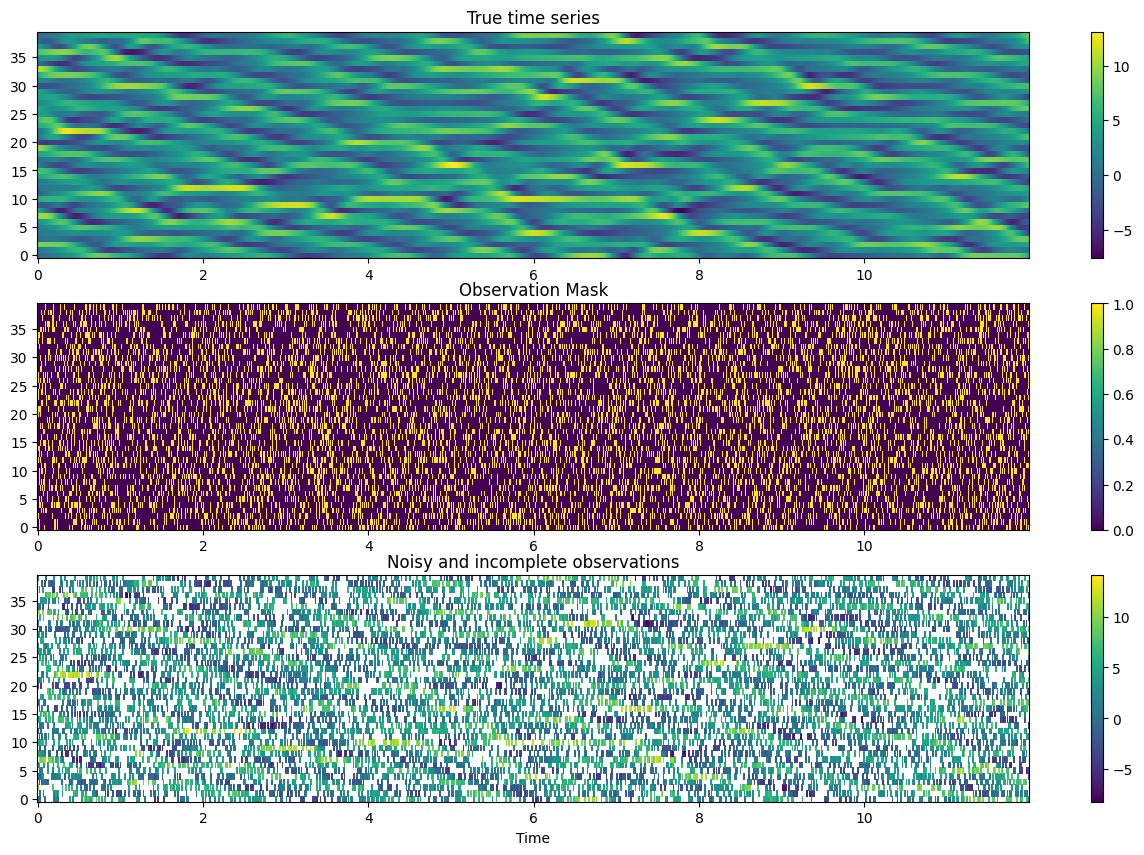

In [5]:
noise_amplitude = 1.0  # observation noise s.d.
p_obs = 0.25 # 75% of the variables are masked

groundtruth, obs_op, observations = random_sparse_noisy_obs(true_ts, noise_amplitude, p_obs)

valid_obs = observations.state.fields['x'][0].T
valid_obs[torch.logical_not(observations.mask.fields['x'][0].T)] = torch.nan

fig, ax = plt.subplots(3, 1, figsize=(16,10))

show_1dseqimg(true_ts.fields['x'][0].T, dt=time_step, ax=ax[0], title="True time series")
show_1dseqimg(observations.mask.fields['x'][0].T, dt=time_step, ax=ax[1], title="Observation Mask")
show_1dseqimg(valid_obs, dt=time_step, ax=ax[2], title="Noisy and incomplete observations", x_label="Time")

Let us define the dynamical system of Lorenz96

In [6]:
# we define a simple one-time-step function in order to fit the ADDA conventions
# In order to use the 4D-Var/EnKF function, you should always have a function like this taking the state, dt, dynamic_inputs and static_inputs

def next_step_function(x: State, dt: float, dynamic_inputs: State, static_inputs: State):
    "this time stepping function expects the input State x to have a single field called 'x'"
    B, T = x.fields.batch_size[:2]
    integrated = forward_operator.integrate(torch.arange(2) * dt, x.fields["x"])[:, -1, :] # integrate over a time step, take the current time
    integrated = integrated.unsqueeze(1)  # re-add time dimension
    new_fields = TensorDict(x=integrated, batch_size=(B, T))
    return State(new_fields, time_axis=x.time_axis + dt)  # return State object, advancing time

# First, we want to see the result without data assimilation

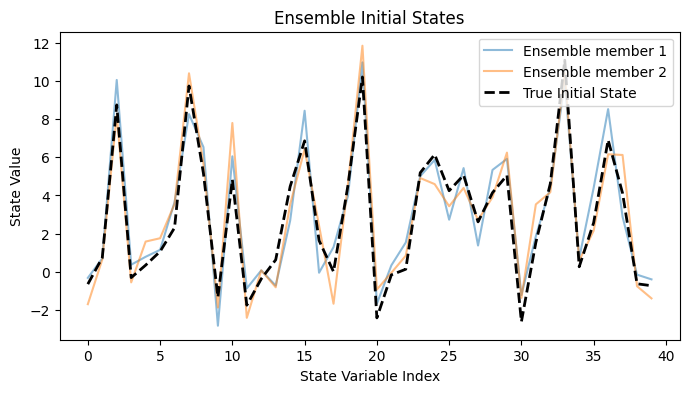

In [7]:
n_members = 2
initial_ensemble_std = 1.0
# Initialize EnKF
enkf_obj = EnKF(
    n_members=n_members,
    n_variables=n_variables,
    initial_ensemble_std=initial_ensemble_std
)

# Create initial ensemble around a naive initialization
true_initial_state = true_ts[:, :1]
ensemble_initial_states = enkf_obj.initialize_ensemble(true_initial_state)
# Plot the ensemble initial states
plt.figure(figsize=(8, 4))
for i in range(n_members):
    plt.plot(ensemble_initial_states.fields["x"][i, 0, :], alpha=0.5, label=f'Ensemble member {i+1}' if i < 5 else "")
plt.plot(true_initial_state.fields["x"][0, 0, :], 'k--', linewidth=2, label='True Initial State')
plt.title('Ensemble Initial States')
plt.xlabel('State Variable Index')
plt.ylabel('State Value')
plt.legend()
plt.show()

In [8]:
# Run Lorenz96 simulations for ensemble_initial_states (State object)
ensemble_trajectories = []
simulation_steps = groundtruth.time_axis.shape[0]  # Number of time steps to simulate
sim_time_axis = torch.arange(0, simulation_steps * time_step, time_step)

print(f"Running simulations for {simulation_steps} time steps...")
print(f"Ensemble initial states shape: {ensemble_initial_states.fields['x'].shape}")

# Extract individual ensemble members from the State object
for i in range(n_members):
    print(f"Simulating ensemble member {i+1}/{n_members}...")
    
    # Extract the i-th ensemble member: shape (n_variables,)
    member_initial_state = ensemble_initial_states.fields['x'][i, 0, :]  # [batch, time, variables]
    
    # Run the simulation for this ensemble member
    trajectory = forward_operator.integrate(
        time=sim_time_axis, 
        state=member_initial_state.unsqueeze(0)  # Add batch dimension for L96Simulator
    ).squeeze()  # Remove batch dimension: shape (time_steps, n_variables)
    
    ensemble_trajectories.append(trajectory)
    
    if (i + 1) % 10 == 0 or i == 0:  # Print progress every 10 members
        print(f"  Completed {i+1} ensemble members. Trajectory shape: {trajectory.shape}")

print(f"\nCompleted simulations for all {n_members} ensemble members!")

# Verify shapes
print(f"Number of ensemble trajectories: {len(ensemble_trajectories)}")
print(f"Each trajectory shape: {ensemble_trajectories[0].shape}")

# Stack all ensemble trajectories for easier analysis
ensemble_trajectories_tensor = torch.stack(ensemble_trajectories)  # Shape: (n_members, time_steps, n_variables)
print(f"Stacked ensemble trajectories shape: {ensemble_trajectories_tensor.shape}")

# Calculate ensemble statistics
ensemble_mean = ensemble_trajectories_tensor.mean(dim=0)  # Mean across ensemble members
ensemble_std = ensemble_trajectories_tensor.std(dim=0)    # Std across ensemble members

print(f"Ensemble mean shape: {ensemble_mean.shape}")
print(f"Ensemble std shape: {ensemble_std.shape}")

# Run true trajectory for comparison
print(f"\nRunning true trajectory for comparison...")
true_sim = forward_operator.integrate(
    time=sim_time_axis, 
    state=true_initial_state.fields['x'][0],
).squeeze()

print(f"True simulation shape: {true_sim.shape}")

# Calculate RMSE for each ensemble member vs true trajectory
rmse_ensemble = []
for i in range(n_members):
    rmse = torch.sqrt(((ensemble_trajectories[i] - true_sim) ** 2).mean(dim=1))  # RMSE over time
    rmse_ensemble.append(rmse)

# Calculate ensemble mean RMSE
ensemble_mean_rmse = torch.sqrt(((ensemble_mean - true_sim) ** 2).mean(dim=1))

# Print final statistics
print(f"\nFinal RMSE values (at t={sim_time_axis[-1]:.2f}s):")
print(f"Ensemble mean RMSE: {ensemble_mean_rmse[-1]:.4f}")
print(f"Individual member RMSEs:")
for i in range(min(5, n_members)):  # Print first 5 members
    print(f"  Member {i+1}: {rmse_ensemble[i][-1]:.4f}")
if n_members > 5:
    print(f"  ... and {n_members-5} more members")

Running simulations for 1200 time steps...
Ensemble initial states shape: torch.Size([2, 1, 40])
Simulating ensemble member 1/2...
  Completed 1 ensemble members. Trajectory shape: torch.Size([1200, 40])
Simulating ensemble member 2/2...

Completed simulations for all 2 ensemble members!
Number of ensemble trajectories: 2
Each trajectory shape: torch.Size([1200, 40])
Stacked ensemble trajectories shape: torch.Size([2, 1200, 40])
Ensemble mean shape: torch.Size([1200, 40])
Ensemble std shape: torch.Size([1200, 40])

Running true trajectory for comparison...
True simulation shape: torch.Size([1200, 40])

Final RMSE values (at t=11.99s):
Ensemble mean RMSE: 4.1363
Individual member RMSEs:
  Member 1: 5.2557
  Member 2: 4.9602


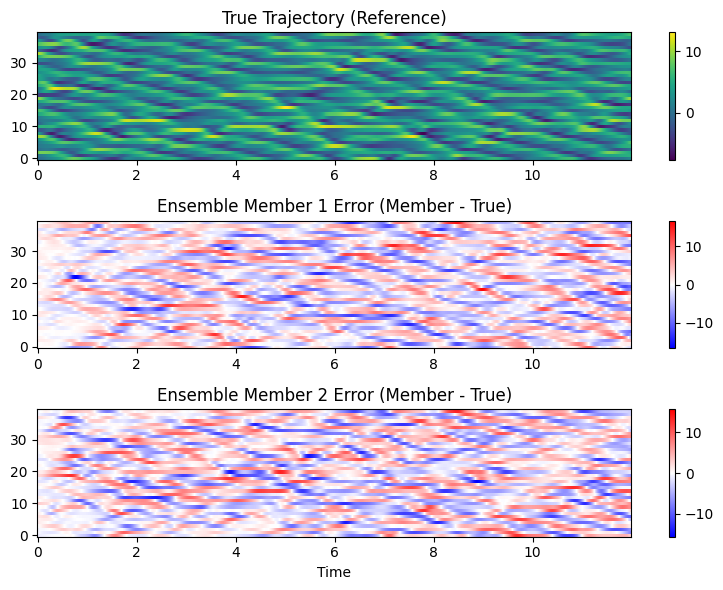

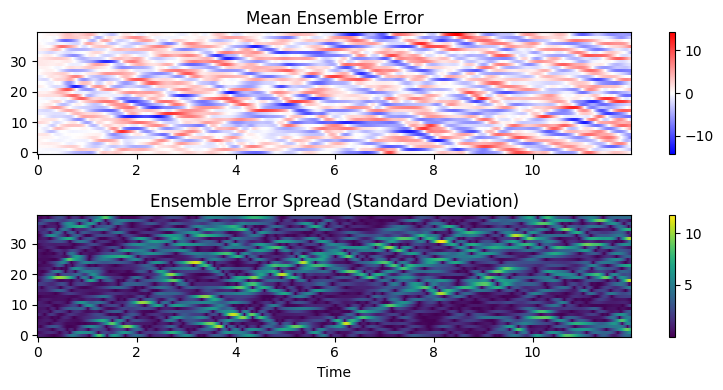

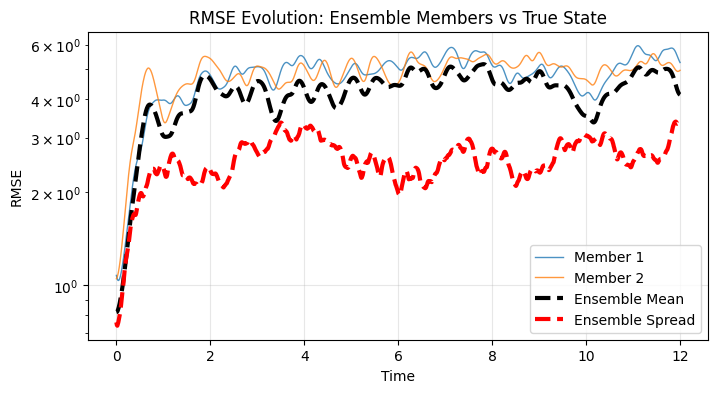


ENSEMBLE ANALYSIS SUMMARY

Final RMSE values (at t=11.99s):
Ensemble mean RMSE: 4.1363
Individual member RMSEs:
  Member 1: 5.2557
  Member 2: 4.9602

Final ensemble spread: 3.4380
Final ensemble mean RMSE: 4.1363
Spread/RMSE ratio: 0.83
  → Ensemble dispersion is reasonable

RMSE at different time points:
Time       Member 1     Member 2     Ens. Mean    Spread      
-----------------------------------------------------------------
0.50       2.6821       3.9459       2.8070       1.9659      
1.00       3.9750       3.4061       3.0439       2.3948      
1.50       3.8231       4.4853       3.6314       2.2470      
1.99       4.8025       5.4211       4.6549       2.3731      


In [9]:
# Usage example:
results = plot_ensemble_analysis(
    ensemble_trajectories=ensemble_trajectories,
    true_sim=true_sim,
    sim_time_axis=sim_time_axis,
    time_step=time_step,
    n_members=n_members,
    max_members_plot=10
)

Create an EnKF object with the number of ensembles specified. Let us examine without data assimilation, 2 initializations slightly differently due to noise will be gradually disturbent over time during the simulation. That behaviour reflects the nature of chaotic system.

# Run EnKF data assimilation with 50 members and initialization is generated by naive_intialization

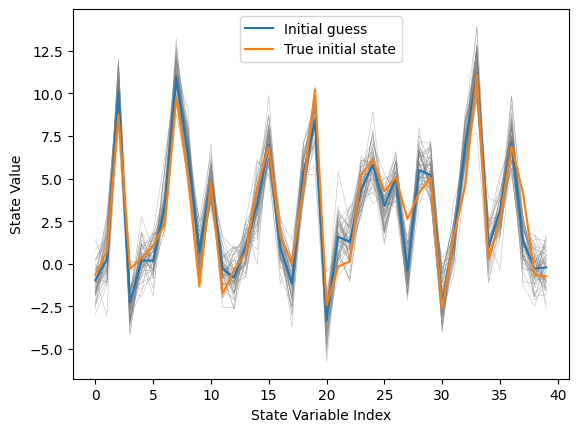

In [10]:
initialization = naive_initialization(observations)  # state estimate for all time points
initialization = initialization[:,:1]  # first time point only
number_of_members = 50
initial_ensemble_std = 1.0
#initial_ensemble_std = 1.0 + torch.randn(n_variables) * 0.1 # define std with a diagonal Gaussian distribution
enkf_obj = EnKF(n_members=number_of_members, n_variables=initialization.fields["x"].shape[-1], initial_ensemble_std=initial_ensemble_std)
enkf_obj.initialize_ensemble(initialization)
# plot 50 ensemble members
for i in range(number_of_members):
    plt.plot(enkf_obj.ensemble.fields['x'][i, 0], alpha=0.5, c='gray', linewidth=0.4)
plt.plot(initialization.fields['x'].squeeze(), label='Initial guess')
plt.plot(true_ts.fields['x'][0, 0], label='True initial state')
plt.xlabel('State Variable Index')
plt.ylabel('State Value')
plt.legend()

In [11]:
# Run data assimilation
t0 = time()
ensemble_states = enkf(
        m_dyn=next_step_function,
        observations=observations,
        obs_op=obs_op,
        x_init=initialization,
        n_members=number_of_members,
        initial_ensemble_std=initial_ensemble_std,
        inflation=1.01
    )

print(f"EnKF assimilation completed!")
print(f'Total computation time: {time() - t0} seconds')

EnKF assimilation completed!
Total computation time: 2.5847370624542236 seconds


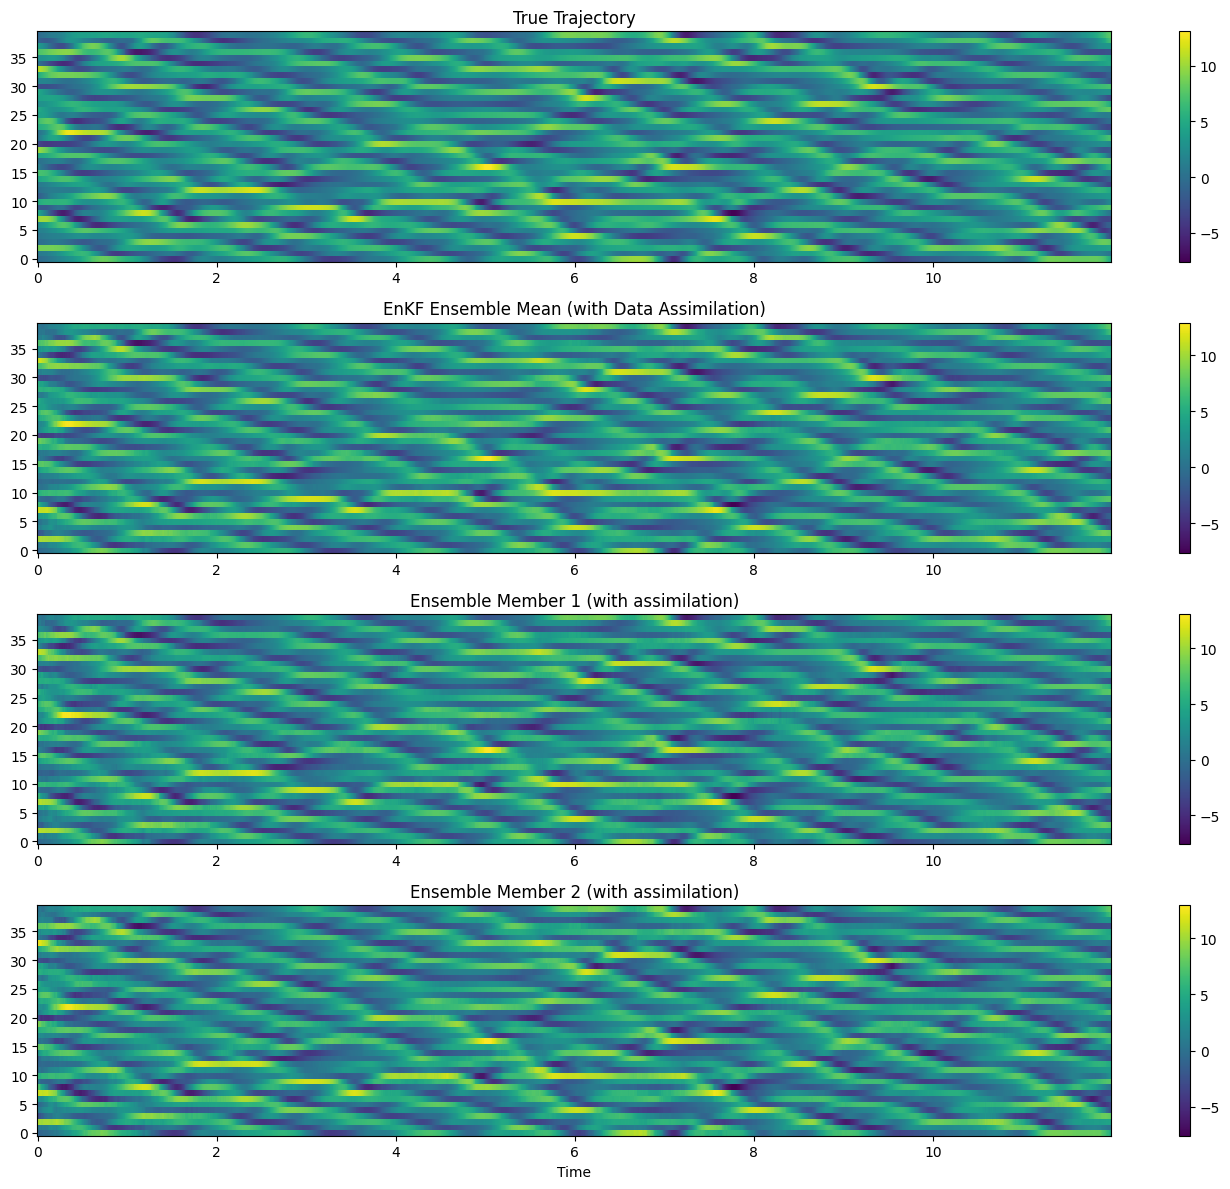

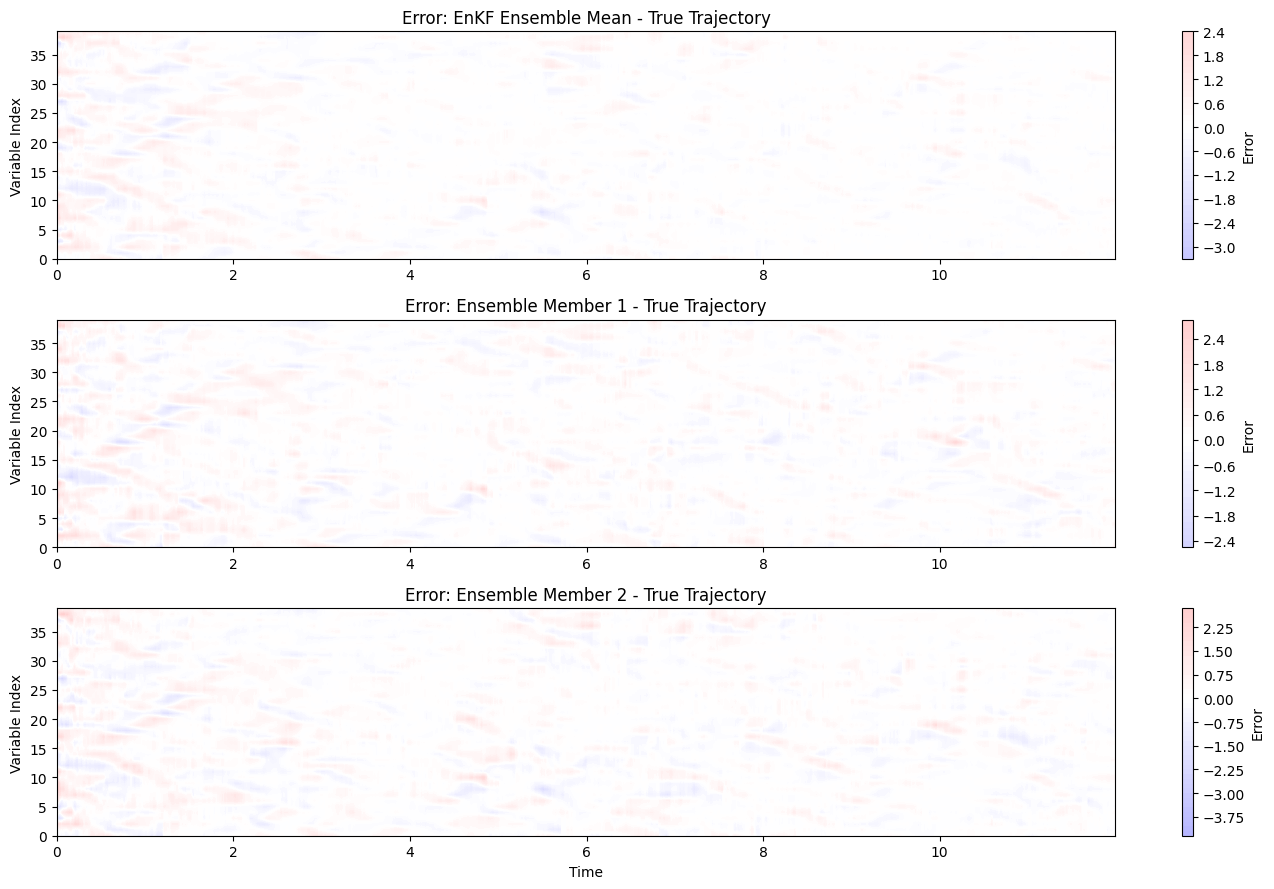


Trajectory Comparison Summary:
EnKF mean trajectory shape: torch.Size([40, 1200])
True trajectory subset shape: torch.Size([40, 1200])
Time steps compared: 1200

Final RMSE at t=11.99s:
EnKF vs True: 0.1384
Ensemble Member 1 vs True: 0.2074
Ensemble Member 2 vs True: 0.1651

EnKF Improvement:
vs Member 1: 33.3%
vs Member 2: 16.2%


In [12]:
# Plot true trajectory, EnKF results, and ensemble members over time
fig, axes = plt.subplots(4, 1, figsize=(14, 12))
n_assimilation_steps = len(observations.state.time_axis)

# Time axis for plotting
assimilation_time_axis = torch.arange(0, n_assimilation_steps * time_step, time_step)
true_trajectory_subset = true_ts.fields['x'][0, :n_assimilation_steps, :].T
ensemble_subset = torch.stack([traj[:n_assimilation_steps, :] for traj in ensemble_states.fields['x']])
ensemble_subset = ensemble_subset[:2]  # Limit to first 2 members for clarity

# 1. True trajectory
show_1dseqimg(true_trajectory_subset, dt=time_step, ax=axes[0], 
              title="True Trajectory", x_label="")

# 2. EnKF ensemble mean (using returned ensemble_states)
# Extract ensemble mean from the returned State object
enkf_full_history = ensemble_states.fields['x']  # Shape: (n_members, n_time_steps, n_variables)
enkf_mean_trajectory = enkf_full_history.mean(dim=0).T  # Shape: (n_variables, n_time_steps)

# Ensure we only use the time steps that match the observations
min_time_steps_enkf = min(enkf_mean_trajectory.shape[1], n_assimilation_steps)
enkf_mean_trajectory = enkf_mean_trajectory[:, :min_time_steps_enkf]

show_1dseqimg(enkf_mean_trajectory, dt=time_step, ax=axes[1], 
              title="EnKF Ensemble Mean (with Data Assimilation)", x_label="")

# 3. & 4. Ensemble members before data assimilation (free forecast)
for i, member_traj in enumerate(ensemble_subset):
    show_1dseqimg(member_traj.T, dt=time_step, ax=axes[2+i], 
                  title=f"Ensemble Member {i+1} (with assimilation)", 
                  x_label="Time" if i == len(ensemble_subset)-1 else "")

plt.tight_layout()
plt.show()

# Plot contour error plots for (1) EnKF mean, (2) Ensemble member 1, (3) Ensemble member 2 vs true trajectory
fig, axes = plt.subplots(3, 1, figsize=(14, 9))
vmax = 15.0  # Set a common color scale limit for better comparison
vmin = -vmax

# 1. Error: EnKF ensemble mean - true trajectory
min_time_steps = min(enkf_mean_trajectory.shape[1], true_trajectory_subset.shape[1])
enkf_error = enkf_mean_trajectory[:, :min_time_steps] - true_trajectory_subset[:, :min_time_steps]

im1 = axes[0].contourf(
    assimilation_time_axis[:min_time_steps].numpy(),
    range(n_variables),
    enkf_error,
    levels=50,
    cmap='bwr',
    vmin=vmin,
    vmax=vmax
)
axes[0].set_title("Error: EnKF Ensemble Mean - True Trajectory")
axes[0].set_ylabel("Variable Index")
plt.colorbar(im1, ax=axes[0], orientation='vertical', label='Error')

# 2. Error: Ensemble member 1 - true trajectory
ens1_error = ensemble_subset[0].T[:, :min_time_steps] - true_trajectory_subset[:, :min_time_steps]
im2 = axes[1].contourf(
    assimilation_time_axis[:min_time_steps].numpy(),
    range(n_variables),
    ens1_error,
    levels=50,
    cmap='bwr',
    vmin=vmin,
    vmax=vmax
)
axes[1].set_title("Error: Ensemble Member 1 - True Trajectory")
axes[1].set_ylabel("Variable Index")
plt.colorbar(im2, ax=axes[1], orientation='vertical', label='Error')

# 3. Error: Ensemble member 2 - true trajectory
ens2_error = ensemble_subset[1].T[:, :min_time_steps] - true_trajectory_subset[:, :min_time_steps]
im3 = axes[2].contourf(
    assimilation_time_axis[:min_time_steps].numpy(),
    range(n_variables),
    ens2_error,
    levels=50,
    cmap='bwr',
    vmin=vmin,
    vmax=vmax
)
axes[2].set_title("Error: Ensemble Member 2 - True Trajectory")
axes[2].set_xlabel("Time")
axes[2].set_ylabel("Variable Index")
plt.colorbar(im3, ax=axes[2], orientation='vertical', label='Error')

plt.tight_layout()
plt.show()

# Print comparison statistics
print(f"\nTrajectory Comparison Summary:")
print(f"EnKF mean trajectory shape: {enkf_mean_trajectory.shape}")
print(f"True trajectory subset shape: {true_trajectory_subset.shape}")
print(f"Time steps compared: {min_time_steps}")

# Calculate final errors
final_enkf_error = torch.sqrt((enkf_error[:, -1] ** 2).mean())
final_ens1_error = torch.sqrt((ens1_error[:, -1] ** 2).mean())
final_ens2_error = torch.sqrt((ens2_error[:, -1] ** 2).mean())

print(f"\nFinal RMSE at t={assimilation_time_axis[min_time_steps-1]:.2f}s:")
print(f"EnKF vs True: {final_enkf_error:.4f}")
print(f"Ensemble Member 1 vs True: {final_ens1_error:.4f}")
print(f"Ensemble Member 2 vs True: {final_ens2_error:.4f}")

# Calculate improvement
improvement_1 = ((final_ens1_error - final_enkf_error) / final_ens1_error) * 100
improvement_2 = ((final_ens2_error - final_enkf_error) / final_ens2_error) * 100

print(f"\nEnKF Improvement:")
print(f"vs Member 1: {improvement_1:.1f}%")
print(f"vs Member 2: {improvement_2:.1f}%")

# Do the same with EnKS

We now run an experiment on the same trajectory and observation scheme, but this time with an ensemble Kalman smoother.

Since the estimation of the states are now also influenced by subsequent observations, the RMSE is expected to significantly decrease.

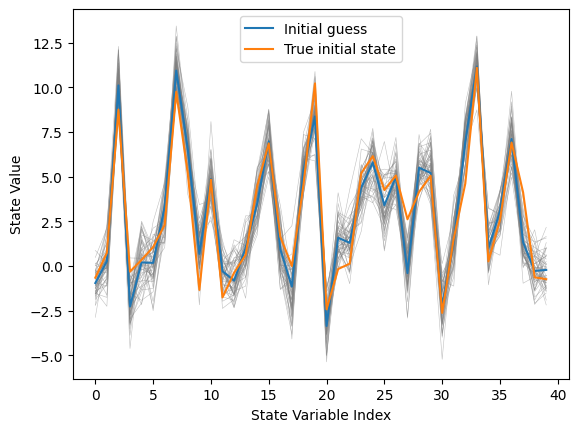

In [13]:
initialization = naive_initialization(observations)  # state estimate for all time points
initialization = initialization[:,:1]  # first time point only
number_of_members = 50
initial_ensemble_std = 1.0
#initial_ensemble_std = 1.0 + torch.randn(n_variables) * 0.1 # define std with a diagonal Gaussian distribution
enks_obj = EnKS(n_members=number_of_members, n_variables=initialization.fields["x"].shape[-1], initial_ensemble_std=initial_ensemble_std, lag=10)
enks_obj.initialize_ensemble(initialization)
# plot 50 ensemble members
for i in range(number_of_members):
    plt.plot(enks_obj.ensemble.fields['x'][i, 0], alpha=0.5, c='gray', linewidth=0.4)
plt.plot(initialization.fields['x'].squeeze(), label='Initial guess')
plt.plot(true_ts.fields['x'][0, 0], label='True initial state')
plt.xlabel('State Variable Index')
plt.ylabel('State Value')
plt.legend()

In [14]:
# Run data assimilation
t0 = time()
ensemble_states_enks = enks(
        m_dyn=next_step_function,
        observations=observations,
        obs_op=obs_op,
        x_init=initialization,
        n_members=number_of_members,
        lag=50,
        initial_ensemble_std=initial_ensemble_std,
        inflation=1.01
    )

print(f"EnKS assimilation completed!")
print(f'Total computation time: {time() - t0} seconds')

EnKS assimilation completed!
Total computation time: 4.659475803375244 seconds


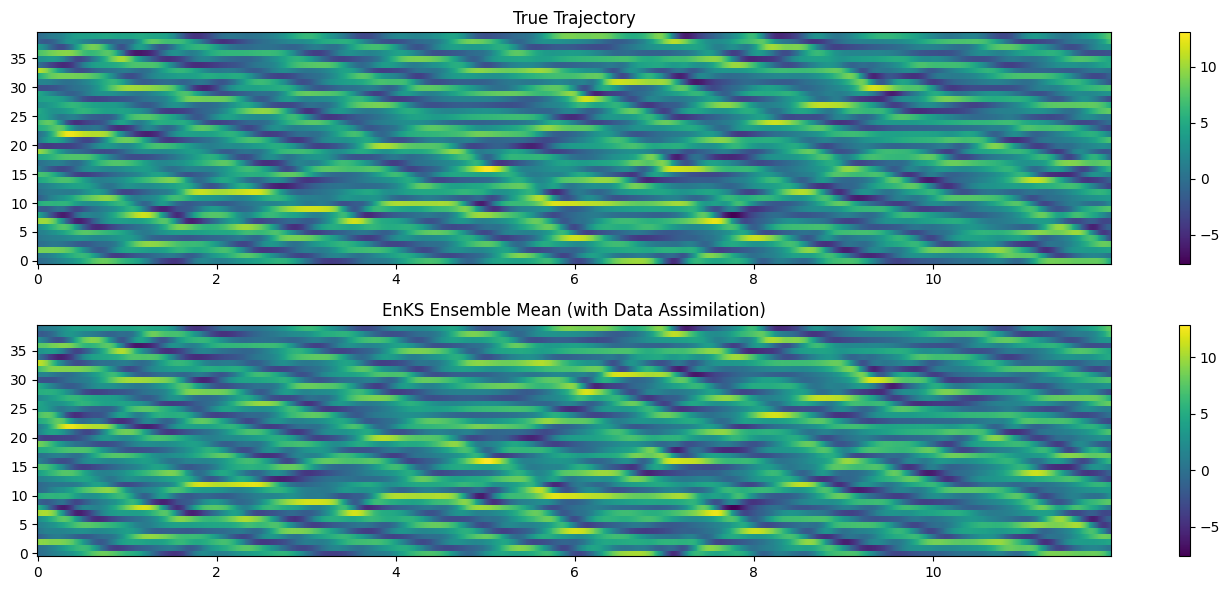

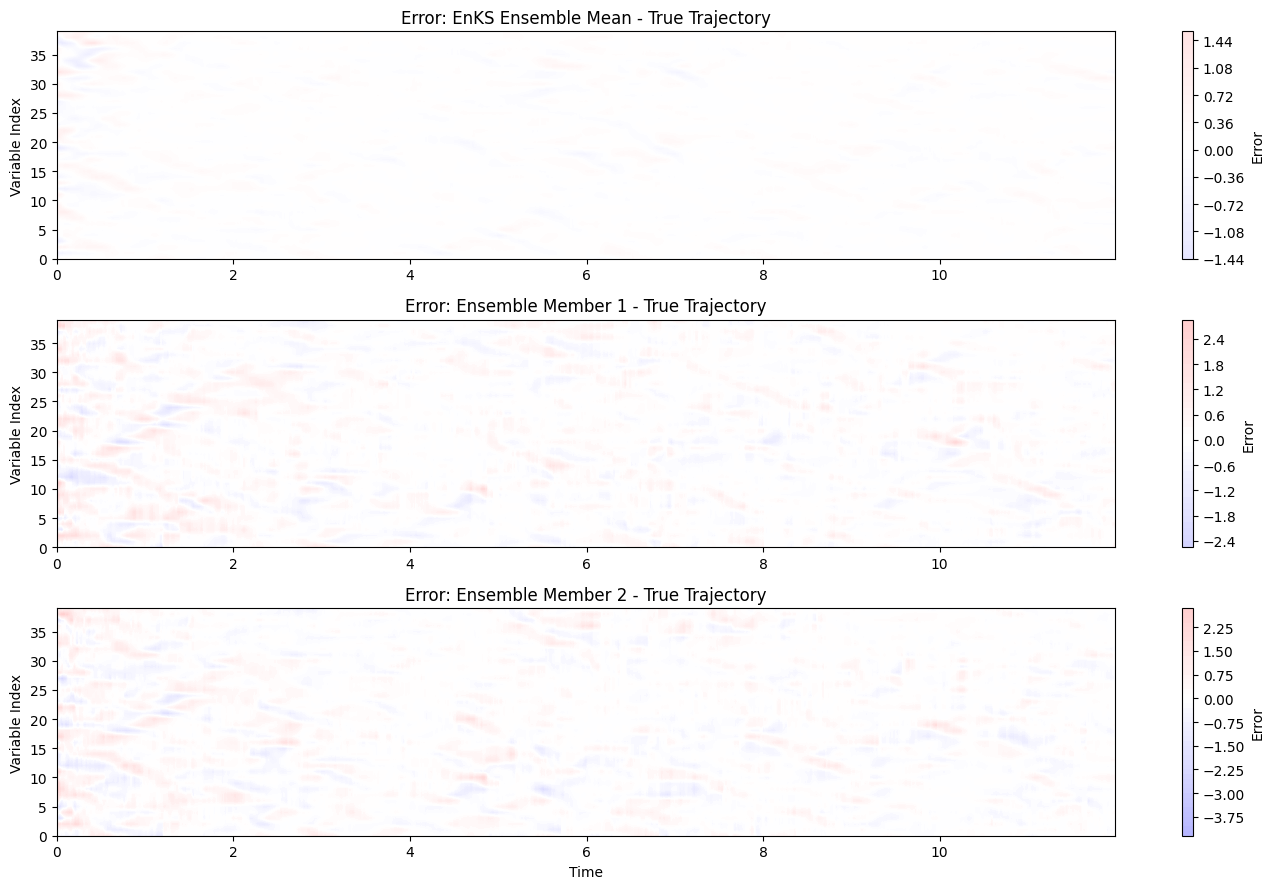


Trajectory Comparison Summary:
EnKS mean trajectory shape: torch.Size([40, 1200])
True trajectory subset shape: torch.Size([40, 1200])
Time steps compared: 1200

Final RMSE at t=11.99s:
EnKS vs True: 0.1438
Ensemble Member 1 vs True: 0.2074
Ensemble Member 2 vs True: 0.1651

EnKS Improvement:
vs Member 1: 30.6%
vs Member 2: 12.9%


In [15]:
# Plot true trajectory, EnKS results, and ensemble members over time
fig, axes = plt.subplots(2, 1, figsize=(14, 6))
n_assimilation_steps = len(observations.state.time_axis)

# Time axis for plotting
assimilation_time_axis = torch.arange(0, n_assimilation_steps * time_step, time_step)
true_trajectory_subset = true_ts.fields['x'][0, :n_assimilation_steps, :].T
ensemble_subset = torch.stack([traj[:n_assimilation_steps, :] for traj in ensemble_states.fields['x']])
ensemble_subset = ensemble_subset[:2]  # Limit to first 2 members for clarity

# 1. True trajectory
show_1dseqimg(true_trajectory_subset, dt=time_step, ax=axes[0], 
              title="True Trajectory", x_label="")

# 2. EnKS ensemble mean (using returned ensemble_states)
# Extract ensemble mean from the returned State object
enks_full_history = ensemble_states_enks.fields['x']  # Shape: (n_members, n_time_steps, n_variables)
enks_mean_trajectory = enks_full_history.mean(dim=0).T  # Shape: (n_variables, n_time_steps)

# Ensure we only use the time steps that match the observations
min_time_steps_enks = min(enks_mean_trajectory.shape[1], n_assimilation_steps)
enks_mean_trajectory = enks_mean_trajectory[:, :min_time_steps_enks]

show_1dseqimg(enks_mean_trajectory, dt=time_step, ax=axes[1], 
              title="EnKS Ensemble Mean (with Data Assimilation)", x_label="")

plt.tight_layout()
plt.show()

# Plot contour error plots for (1) EnKS mean, (2) Ensemble member 1, (3) Ensemble member 2 vs true trajectory
fig, axes = plt.subplots(3, 1, figsize=(14, 9))
vmax = 15.0  # Set a common color scale limit for better comparison
vmin = -vmax

# 1. Error: EnKS ensemble mean - true trajectory
min_time_steps = min(enks_mean_trajectory.shape[1], true_trajectory_subset.shape[1])
enks_error = enks_mean_trajectory[:, :min_time_steps] - true_trajectory_subset[:, :min_time_steps]

im1 = axes[0].contourf(
    assimilation_time_axis[:min_time_steps].numpy(),
    range(n_variables),
    enks_error,
    levels=50,
    cmap='bwr',
    vmin=vmin,
    vmax=vmax
)
axes[0].set_title("Error: EnKS Ensemble Mean - True Trajectory")
axes[0].set_ylabel("Variable Index")
plt.colorbar(im1, ax=axes[0], orientation='vertical', label='Error')

# 2. Error: Ensemble member 1 - true trajectory
ens1_error = ensemble_subset[0].T[:, :min_time_steps] - true_trajectory_subset[:, :min_time_steps]
im2 = axes[1].contourf(
    assimilation_time_axis[:min_time_steps].numpy(),
    range(n_variables),
    ens1_error,
    levels=50,
    cmap='bwr',
    vmin=vmin,
    vmax=vmax
)
axes[1].set_title("Error: Ensemble Member 1 - True Trajectory")
axes[1].set_ylabel("Variable Index")
plt.colorbar(im2, ax=axes[1], orientation='vertical', label='Error')

# 3. Error: Ensemble member 2 - true trajectory
ens2_error = ensemble_subset[1].T[:, :min_time_steps] - true_trajectory_subset[:, :min_time_steps]
im3 = axes[2].contourf(
    assimilation_time_axis[:min_time_steps].numpy(),
    range(n_variables),
    ens2_error,
    levels=50,
    cmap='bwr',
    vmin=vmin,
    vmax=vmax
)
axes[2].set_title("Error: Ensemble Member 2 - True Trajectory")
axes[2].set_xlabel("Time")
axes[2].set_ylabel("Variable Index")
plt.colorbar(im3, ax=axes[2], orientation='vertical', label='Error')

plt.tight_layout()
plt.show()

# Print comparison statistics
print(f"\nTrajectory Comparison Summary:")
print(f"EnKS mean trajectory shape: {enks_mean_trajectory.shape}")
print(f"True trajectory subset shape: {true_trajectory_subset.shape}")
print(f"Time steps compared: {min_time_steps}")

# Calculate final errors
final_enks_error = torch.sqrt((enks_error[:, -1] ** 2).mean())
final_ens1_error = torch.sqrt((ens1_error[:, -1] ** 2).mean())
final_ens2_error = torch.sqrt((ens2_error[:, -1] ** 2).mean())

print(f"\nFinal RMSE at t={assimilation_time_axis[min_time_steps-1]:.2f}s:")
print(f"EnKS vs True: {final_enks_error:.4f}")
print(f"Ensemble Member 1 vs True: {final_ens1_error:.4f}")
print(f"Ensemble Member 2 vs True: {final_ens2_error:.4f}")

# Calculate improvement
improvement_1 = ((final_ens1_error - final_enks_error) / final_ens1_error) * 100
improvement_2 = ((final_ens2_error - final_enks_error) / final_ens2_error) * 100

print(f"\nEnKS Improvement:")
print(f"vs Member 1: {improvement_1:.1f}%")
print(f"vs Member 2: {improvement_2:.1f}%")

# Comparison of EnKF and EnKS results

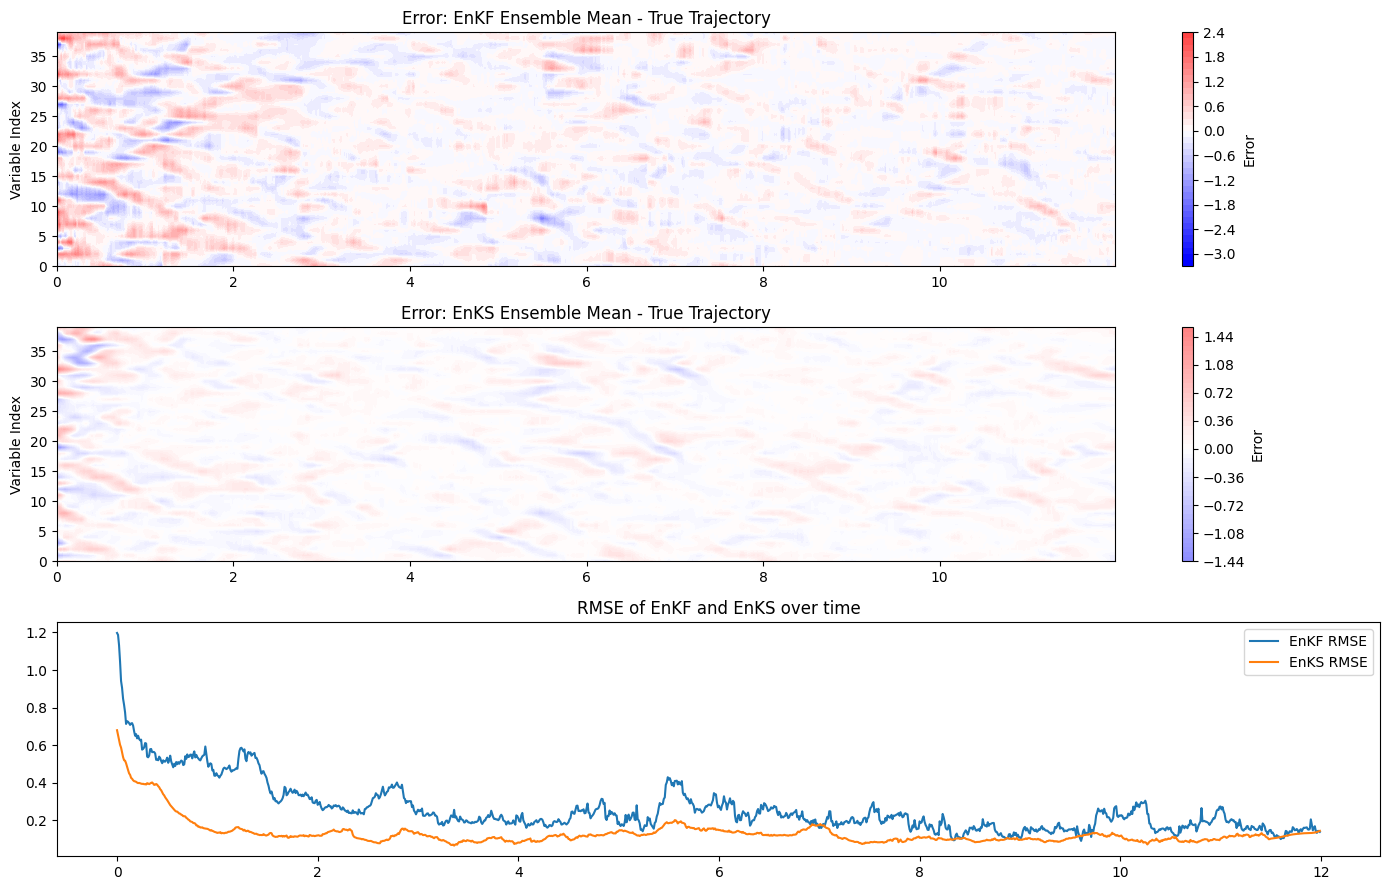

In [16]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9))

vmax = max(torch.max(torch.abs(enkf_error)), torch.max(torch.abs(enks_error)))
vmin = - vmax

im0 = axes[0].contourf(
    assimilation_time_axis[:min_time_steps].numpy(),
    range(n_variables),
    enkf_error,
    levels=50,
    cmap='bwr',
    vmin=vmin,
    vmax=vmax
)
axes[0].set_title("Error: EnKF Ensemble Mean - True Trajectory")
axes[0].set_ylabel("Variable Index")
plt.colorbar(im0, ax=axes[0], orientation='vertical', label='Error')

im1 = axes[1].contourf(
    assimilation_time_axis[:min_time_steps].numpy(),
    range(n_variables),
    enks_error,
    levels=50,
    cmap='bwr',
    vmin=vmin,
    vmax=vmax
)
axes[1].set_title("Error: EnKS Ensemble Mean - True Trajectory")
axes[1].set_ylabel("Variable Index")
plt.colorbar(im1, ax=axes[1], orientation='vertical', label='Error')

RMSE_over_time_enkf = torch.sqrt(torch.mean(enkf_error **2, dim=0))
RMSE_over_time_enks = torch.sqrt(torch.mean(enks_error **2, dim=0))
axes[2].plot(assimilation_time_axis[:min_time_steps], RMSE_over_time_enkf, label=f'EnKF RMSE')
axes[2].plot(assimilation_time_axis[:min_time_steps], RMSE_over_time_enks, label=f'EnKS RMSE')
#axes[2].plot(assimilation_time_axis[:min_time_steps], RMSE_over_time_enkf, label=f'EnKF RMSE: global mean = {round(torch.mean(RMSE_over_time_enkf).item(), 3)}')
#axes[2].plot(assimilation_time_axis[:min_time_steps], RMSE_over_time_enks, label=f'EnKS RMSE: global mean = {round(torch.mean(RMSE_over_time_enks).item(), 3)}')
axes[2].set_title("RMSE of EnKF and EnKS over time")

plt.legend()
plt.tight_layout()
plt.show()

As expected, the smoother enables a significant decrease of the RMSE with regards to the filter.